In [1]:
%matplotlib ipympl

from math import prod
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

from microhhpy.io import read_case_out

In [2]:

"""
Scaling uses a fixed time step.
At cold start, dynamics are undeveloped so the dynamic dt is too large,
causing statistics/IO/radiation to be called unrealistically often.
These time steps were estimated from longer simulations on the ECMWF HPC.
"""
dt_200 = 4.4
dt_400 = 5.1
dt_800 = 3.5    # Yikes; limited by diffusion because of the pancake grid cells.

cores_per_node = 128


class Weak_scaling:
    """
    Read single weak scaling experiment.
    """
    def __init__(self, path, name, grid, dt, configs):
        self.name = name
        self.configs = configs
        self.dt = dt
        self.grid = grid

        n = len(configs)

        self.nodes = np.zeros(n, dtype=int)
        self.ncells = np.zeros(n, dtype=int)
        self.cpudt_min = np.zeros(n)
        self.cpudt_mean = np.zeros(n)
        self.cpudt_median = np.zeros(n)
        self.cpudt_max = np.zeros(n)
        self.sdpd_mean = np.zeros(n)

        self.out = []
        sbu_sum = 0

        for i, (nx, ny) in enumerate(configs):
            out_file = f'{path}/{name}_{nx}x{ny}.out'
            out = read_case_out(out_file)[0]
            self.out.append(out)

            # Always skip first row; does not include computations.
            cpudt = out['cpudt'][1:]
            sdpd  = out['sdpd'][1:]

            if cpudt.size < 1:
                print(f'Error: {name}_{nx}x{ny}: case.out empty!')
            else:
                self.nodes[i] = nx*ny
                self.cpudt_min[i] = np.min(cpudt)
                self.cpudt_mean[i] = np.mean(cpudt)
                self.cpudt_median[i] = np.median(cpudt)
                self.cpudt_max[i] = np.max(cpudt)
                self.sdpd_mean[i] = np.mean(sdpd)
                self.ncells[i] = prod(grid) * self.nodes[i]

        # From proposal:  Ti* = time/iter * cores / problem size
        #                 Tf* = time to solution * cores / problem size
        self.ti_star = self.cpudt_mean * self.nodes * cores_per_node / self.ncells

        # What to use for time to solution?
        total_days = 1
        self.time_to_solution = total_days / self.sdpd_mean * 86400
        self.tf_star = self.time_to_solution * self.nodes * cores_per_node / self.ncells


class Strong_scaling:
    """
    Get strong scaling from multiple weak scaling tests.
    """
    def __init__(self, cases):
        N = len(cases)

        self.nodes  = np.zeros(N, dtype=np.int32)
        self.cpudt  = np.zeros(N)     # Wall clock time per iteration (s)
        self.sdpd   = np.zeros(N)     # Simulated days-per-day (-)
        self.ti     = np.zeros(N)     # Normalised time/iter (s)
        self.tf     = np.zeros(N)     # Normalised time to solution (s)

        for i,case in enumerate(cases):
            self.nodes[i]  = cases[i].nodes[-1]
            self.cpudt[i]  = cases[i].cpudt_mean[-1]
            self.sdpd[i]   = cases[i].sdpd_mean[-1]
            self.ti[i]     = cases[i].ti_star[-1]
            self.tf[i]     = cases[i].tf_star[-1]

        self.cores = self.nodes * 128
        self.sbud = 24/self.sdpd * self.cores

        # Index of most efficient config.
        self.iref = np.argmin(self.sbud)


class Scaling:
    def __init__(self, path):
        self.path = path

        self.r200_128_16x1 = Weak_scaling(path, '200_128_16x1', (1920, 2048, 128), dt_200, [(1,1), (2,1), (4,1), (8,1), (16,1)])
        self.r200_128_16x2 = Weak_scaling(path, '200_128_16x2', (1920, 1024, 128), dt_200, [(1,1), (1,2), (2,2), (4,2), (8,2), (16,2)])
        self.r200_128_16x4 = Weak_scaling(path, '200_128_16x4', (1920, 512,  128), dt_200, [(1,1), (1,2), (1,4), (2,4), (4,4), (8,4), (16,4)])
        self.r200_128_16x8 = Weak_scaling(path, '200_128_16x8', (1920, 256,  128), dt_200, [(1,1), (1,2), (1,4), (1,8), (2,8), (4,8), (8,8), (16,8)])

        self.r400_128_4x1  = Weak_scaling(path, '400_128_4x1',  (3840, 1024, 128), dt_400, [(1,1), (2,1), (4,1)])
        self.r400_128_8x1  = Weak_scaling(path, '400_128_8x1',  (1920, 1024, 128), dt_400, [(1,1), (2,1), (4,1), (8,1)])
        self.r400_128_16x1 = Weak_scaling(path, '400_128_16x1', (960,  1024, 128), dt_400, [(1,1), (2,1), (4,1), (8,1), (16,1)])
        self.r400_128_16x2 = Weak_scaling(path, '400_128_16x2', (960,  512,  128), dt_400, [(1,1), (1,2), (2,2), (4,2), (8,2), (16,2)])
        self.r400_128_16x4 = Weak_scaling(path, '400_128_16x4', (960,  256,  128), dt_400, [(1,1), (1,2), (1,4), (2,4), (4,4), (8,4), (16,4)])

        self.r800_128_4x1  = Weak_scaling(path, '800_128_4x1',  (1920, 512, 128),  dt_800, [(1,1), (2,1), (4,1)])
        self.r800_128_8x1  = Weak_scaling(path, '800_128_8x1',  (960,  512, 128),  dt_800, [(1,1), (2,1), (4,1), (8,1)])
        self.r800_128_16x1 = Weak_scaling(path, '800_128_16x1', (480,  512, 128),  dt_800, [(1,1), (2,1), (4,1), (8,1), (16,1)])

        self.r200 = Strong_scaling([self.r200_128_16x1, self.r200_128_16x2, self.r200_128_16x4, self.r200_128_16x8])
        self.r400 = Strong_scaling([self.r400_128_4x1, self.r400_128_8x1, self.r400_128_16x1, self.r400_128_16x2, self.r400_128_16x4])
        self.r800 = Strong_scaling([self.r800_128_4x1, self.r800_128_8x1, self.r800_128_16x1])


case = Scaling('out_lumi')

case.r200_128_16x2.out[0]['cpudt'][1:].mean()

np.float64(4.837236097560975)

## Section 2.6.2.1: Weak and strong scaling

Weak: building up to the full 6000 x 400 km2 domain from smaller building blocks. Required but less important since we are dealing with a fixed problem size from the MIP.

Strong: code performance on full 6000 x 400 km2 domain when increasing number of cores for faster time to solution. Important for balancing computational costs vs time-to-solution.

**NOTE**: solid marker indicated our choice as balance between costs and time-to-solution.

In [3]:
# Chosen configuration for balance SDPD and SBUs.
chosen_200 = 2
chosen_400 = 3
chosen_800 = 2

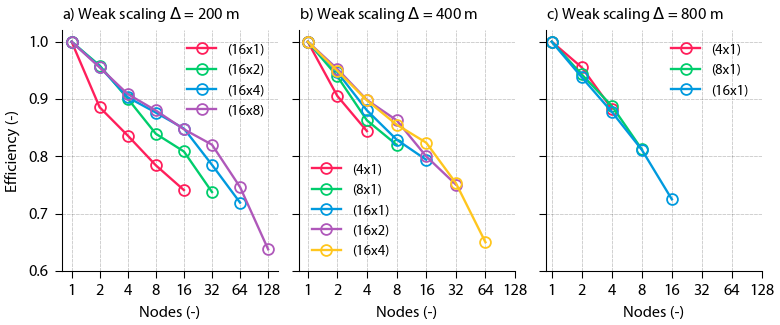

In [4]:
def plot_weak(case, ax, *args, **kwargs):
    ax.plot(case.nodes, case.cpudt_mean[0]/case.cpudt_mean, *args, mfc='none', **kwargs)

fig, (ax_w1, ax_w2, ax_w3) = plt.subplots(1, 3, figsize=(6, 2.5), layout='constrained', sharey=True)

ax_w1.set_title(r'a) Weak scaling $\Delta$ = 200 m', loc='left')
plot_weak(case.r200_128_16x1, ax_w1, '-o', color='C0', label=r'(16x1)')
plot_weak(case.r200_128_16x2, ax_w1, '-o', color='C1', label=r'(16x2)')
plot_weak(case.r200_128_16x4, ax_w1, '-o', color='C2', label=r'(16x4)')
plot_weak(case.r200_128_16x8, ax_w1, '-o', color='C3', label=r'(16x8)')

ax_w2.set_title(r'b) Weak scaling $\Delta$ = 400 m', loc='left')
plot_weak(case.r400_128_4x1,  ax_w2, '-o', color='C0', label=r'(4x1)')
plot_weak(case.r400_128_8x1,  ax_w2, '-o', color='C1', label=r'(8x1)')
plot_weak(case.r400_128_16x1, ax_w2, '-o', color='C2', label=r'(16x1)')
plot_weak(case.r400_128_16x2, ax_w2, '-o', color='C3', label=r'(16x2)')
plot_weak(case.r400_128_16x4, ax_w2, '-o', color='C4', label=r'(16x4)')

ax_w3.set_title(r'c) Weak scaling $\Delta$ = 800 m', loc='left')
plot_weak(case.r800_128_4x1,  ax_w3, '-o', color='C0', label=r'(4x1)')
plot_weak(case.r800_128_8x1,  ax_w3, '-o', color='C1', label=r'(8x1)')
plot_weak(case.r800_128_16x1, ax_w3, '-o', color='C2', label=r'(16x1)')

for ax in [ax_w1, ax_w2, ax_w3]:
    ax.legend(fontsize=8)
    ax.set_ylim(0.6, 1.02)
    ax.minorticks_off()
    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.set_xticks([1, 2, 4, 8, 16, 32, 64, 128])
    ax.grid()
    ax.set_xlabel('Nodes (-)')

ax_w1.set_ylabel('Efficiency (-)')

plt.savefig('figures/weak_scaling.png')
plt.savefig('figures/weak_scaling.pdf')

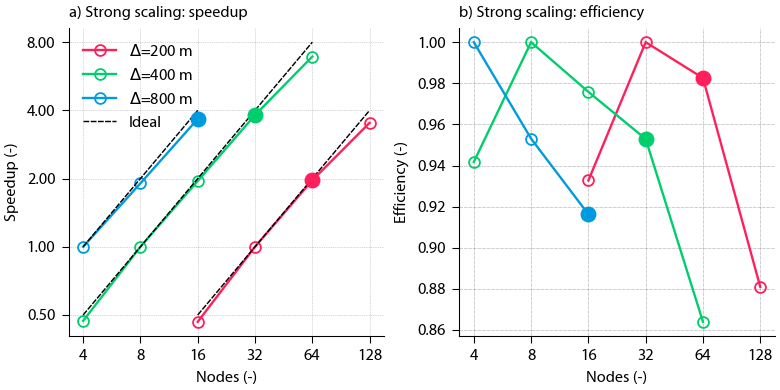

In [5]:
def plot_strong_efficiency(case, ax, chosen=None, *args, **kwargs):
    kwargs.setdefault('mfc', 'none')
    ref = case.iref
    ideal = case.nodes / case.nodes[ref]
    efficiency = (case.cpudt[ref] / case.cpudt) / ideal
    line, = ax.plot(case.nodes, efficiency, *args, **kwargs)

    if chosen is not None:
        ax.plot(case.nodes[chosen], efficiency[chosen],
                marker=line.get_marker(), color=line.get_color(),
                markersize=line.get_markersize()*1.3,
                linestyle='none', label='_nolegend_')


def plot_strong_speedup(case, ax, chosen=None, *args, **kwargs):
    kwargs.setdefault('mfc', 'none')
    ref     = case.iref
    speedup = case.cpudt[ref] / case.cpudt
    ideal   = case.cores / case.cores[ref]
    line, = ax.plot(case.nodes, speedup, *args, **kwargs)
    ax.plot(case.nodes, ideal, '--', color='k', linewidth=0.8, label='_nolegend_')

    if chosen is not None:
        ax.plot(case.nodes[chosen], speedup[chosen],
                marker=line.get_marker(), color=line.get_color(),
                markersize=line.get_markersize()*1.3,
                linestyle='none', label='_nolegend_')


fig, (ax_sp, ax_ef) = plt.subplots(1, 2, figsize=(6, 3), layout='constrained')

ax_sp.set_title(r'a) Strong scaling: speedup', loc='left')
plot_strong_speedup(case.r200, ax_sp, chosen_200, '-o', color='C0', label=r'$\Delta$=200 m')
plot_strong_speedup(case.r400, ax_sp, chosen_400, '-o', color='C1', label=r'$\Delta$=400 m')
plot_strong_speedup(case.r800, ax_sp, chosen_800, '-o', color='C2', label=r'$\Delta$=800 m')
ax_sp.plot([], [], '--', color='k', linewidth=0.8, label='Ideal')
ax_sp.legend(loc='upper left')
ax_sp.set_xlabel('Nodes (-)')
ax_sp.set_ylabel('Speedup (-)')
ax_sp.set_xscale('log', base=2)
ax_sp.set_yscale('log', base=2)
ax_sp.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax_sp.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax_sp.set_xticks([4, 8, 16, 32, 64, 128])
ax_sp.grid(which='both', linestyle=':', linewidth=0.5)
ax_sp.minorticks_off()

ax_ef.set_title(r'b) Strong scaling: efficiency', loc='left')
plot_strong_efficiency(case.r200, ax_ef, chosen_200, '-o', color='C0')
plot_strong_efficiency(case.r400, ax_ef, chosen_400, '-o', color='C1')
plot_strong_efficiency(case.r800, ax_ef, chosen_800, '-o', color='C2')
ax_ef.set_ylabel('Efficiency (-)')
ax_ef.set_xlabel('Nodes (-)')
ax_ef.set_xscale('log', base=2)
ax_ef.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax_ef.set_xticks([4, 8, 16, 32, 64, 128])
ax_ef.minorticks_off()
ax_ef.grid()

plt.savefig('figures/strong_scaling.png')
plt.savefig('figures/strong_scaling.pdf')


## Balancing waiting time (SDPD) versus simulation costs.

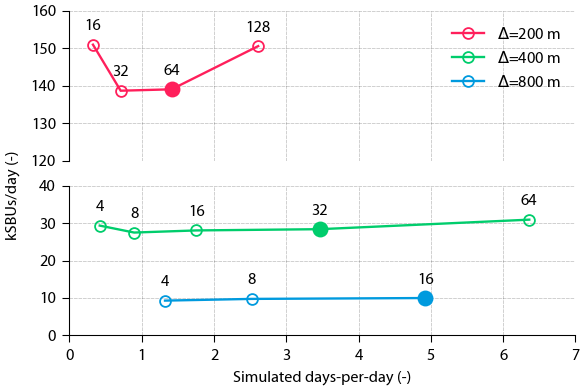

In [6]:
def broken_yaxis(ylim_bottom, ylim_top, figsize=None, d=0.1, ylabel=None, **subplot_kwargs):
    """
    Create a broken y-axis figure with two y-ranges.

    Parameters
    ----------
    ylim_bottom : tuple
        (ymin, ymax) for the bottom axes (lower data range).
    ylim_top : tuple
        (ymin, ymax) for the top axes (upper data range).
    figsize : tuple, optional
        Figure size passed to plt.subplots.
    ylabel : str, optional
        Shared y-axis label centered across both axes.
    **subplot_kwargs
        Additional kwargs passed to plt.subplots.

    Returns
    -------
    fig : Figure
    ax_top : Axes  (top panel, higher y-range)
    ax_bot : Axes  (bottom panel, lower y-range)
    """
    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, sharex=True, layout='constrained', figsize=figsize, **subplot_kwargs
    )
    #fig.subplots_adjust(hspace=d)

    ax_top.set_ylim(*ylim_top)
    ax_bot.set_ylim(*ylim_bottom)

    # Hide the spines between the two axes
    ax_top.spines.bottom.set_visible(False)
    ax_bot.spines.top.set_visible(False)

    # Hide x ticks/labels on top axis without disabling the axis itself (grid still works)
    ax_top.tick_params(axis='x', which='both', length=0, labelbottom=False)

    # Add single y-label.
    if ylabel is not None:
        fig.supylabel(ylabel, size=9)

    return fig, ax_top, ax_bot


def plot_sdpd_sbud(case, chosen, ax, *args, **kwargs):
    kwargs.setdefault('mfc', 'none')
    line, = ax.plot(case.sdpd, case.sbud/1000, *args, **kwargs)
    for x, y, n in zip(case.sdpd, case.sbud/1000, case.nodes):
        ax.annotate(str(n), (x, y), textcoords='offset points', xytext=(0, 8), fontsize=9, ha='center')

    if chosen is not None:
        ax.plot(case.sdpd[chosen], (case.sbud/1000)[chosen], *args,
                color=line.get_color(), markersize=line.get_markersize()*1.3,
                label='_nolegend_')


fig, ax_top, ax_bot = broken_yaxis(
    ylim_bottom=(0, 40),
    ylim_top=(120, 160),
    figsize=(4.5, 3),
    ylabel='kSBUs/day (-)')

plot_sdpd_sbud(case.r200, chosen_200, ax_top, '-o', color='C0', label=r'$\Delta$=200 m')
plot_sdpd_sbud(case.r400, chosen_400, ax_bot, '-o', color='C1', label=r'$\Delta$=400 m')
plot_sdpd_sbud(case.r800, chosen_800, ax_bot, '-o', color='C2', label=r'$\Delta$=800 m')

for ax in [ax_top, ax_bot]:
    ax.minorticks_off()
    ax.grid()
    ax.set_xlim(0,7)

handles, labels = [], []
for ax in [ax_top, ax_bot]:
    h, l = ax.get_legend_handles_labels()
    handles += h
    labels += l
ax_top.legend(handles, labels)

plt.xlabel('Simulated days-per-day (-)')

plt.savefig(f'figures/sbu_sdpd.png')
plt.savefig(f'figures/sbu_sdpd.pdf')

## Chosen options, efficiency, and SDPD/costs

In [7]:
def print_chosen(c, i, label):
    print(rf'{label}: Simulated days/day = {c.sdpd[i]:.1f}, kSBUs/day = {c.sbud[i]:.1f}')

print_chosen(case.r200, chosen_200, label=r'D=200 m')
print_chosen(case.r400, chosen_400, label=r'D=400 m')
print_chosen(case.r800, chosen_800, label=r'D=800 m')

D=200 m: Simulated days/day = 1.4, kSBUs/day = 139071.4
D=400 m: Simulated days/day = 3.5, kSBUs/day = 28363.7
D=800 m: Simulated days/day = 4.9, kSBUs/day = 9982.6


## Section 2.6.2.3: Time-to-solution

The interpretation of these numbers is weird; I think they are mainly for comparison against similar codes? From template:

$$T_i^* = \frac{t_i \cdot N_c}{N_e}$$

$$T_f^* = \frac{t_f \cdot N_c}{N_e}$$

with $t_i$ the wall-clock time per iteration (s), $t_f$ the total time to solution (s),
$N_c$ the number of cores, and $N_e$ the number of grid points.



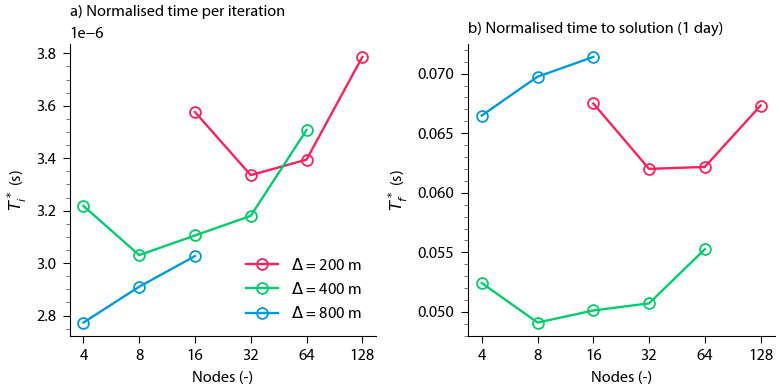

In [8]:

plt.figure(figsize=(6, 3), layout='constrained')
ax=plt.subplot(121)
plt.title('a) Normalised time per iteration', loc='left')
plt.plot(case.r200.nodes, case.r200.ti, '-o', mfc='none', label=r'$\Delta$ = 200 m')
plt.plot(case.r400.nodes, case.r400.ti, '-o', mfc='none', label=r'$\Delta$ = 400 m')
plt.plot(case.r800.nodes, case.r800.ti, '-o', mfc='none', label=r'$\Delta$ = 800 m')
#ax.set_ylim(bottom=0)
ax.set_xscale('log', base=2)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks([4, 8, 16, 32, 64, 128])
plt.ylabel(r'$T_i^*$ (s)')
plt.xlabel('Nodes (-)')
plt.legend()

ax=plt.subplot(122)
plt.title('b) Normalised time to solution (1 day)', loc='left')
plt.plot(case.r200.nodes, case.r200.tf, '-o', mfc='none')
plt.plot(case.r400.nodes, case.r400.tf, '-o', mfc='none')
plt.plot(case.r800.nodes, case.r800.tf, '-o', mfc='none')
#ax.set_ylim(bottom=0)
ax.set_xscale('log', base=2)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks([4, 8, 16, 32, 64, 128])
plt.ylabel(r'$T_f^*$ (s)')
plt.xlabel('Nodes (-)')

plt.savefig('figures/time_to_solution.png')
plt.savefig('figures/time_to_solution.pdf')